Graficos
dataset 1 : https://www.kaggle.com/datasets/saidaantonyan/iris-classifier-with-knn?select=Iris.csv 
dataset 2 : https://www.kaggle.com/datasets/pabloa/wine-magazine?select=winemag-data_first150k.csv

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datagenerator import DataGenerator

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
datagen = DataGenerator()

In [3]:
df1 = pd.DataFrame()
dataset = datagen.download_dataset_zip("saidaantonyan/iris-classifier-with-knn") 
csv_dir =datagen.extract_zip_files(dataset)
df1 = datagen.create_csv(csv_dir)

Descargando dataset desde Kaggle...


100%|██████████| 1.28k/1.28k [00:00<00:00, 2.38MB/s]

Extracting files...
Ruta al dataset: /home/codespace/.cache/kagglehub/datasets/saidaantonyan/iris-classifier-with-knn/versions/1
No se encontró archivo ZIP pero se detectaron archivos CSV; se asume que el dataset ya se encuentra extraído.
Leyendo /home/codespace/.cache/kagglehub/datasets/saidaantonyan/iris-classifier-with-knn/versions/1/Iris.csv...
Creando/actualizando 
cvs creado correctamente en 


In [4]:
df1.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
df2= datagen.leer_ruta("/workspaces/AD20252_1/SRC/Clases AD/static/csv/winemag-data_first150k.csv")
df2.head(5)

,country,designation,points,price,province,region_1,region_2,variety,winery,last_year_points
0,US,Martha's Vineyard,96.0,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz,94
1,Spain,Carodorum Selección Especial Reserva,96.0,110.0,Northern Spain,Toro,NaN,Tinta de Toro,Bodega Carmen Rodríguez,92
2,US,Special Selected Late Harvest,96.0,90.0,California,Knights Valley,Sonoma,Sauvignon Blanc,Macauley,100
3,US,Reserve,96.0,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi,94
4,France,La Brûlade,95.0,66.0,Provence,Bandol,NaN,Provence red blend,Domaine de la Bégude,94


# Libreria MATPLOTLIB

# Graficos de Barras

<Axes: xlabel='country'>

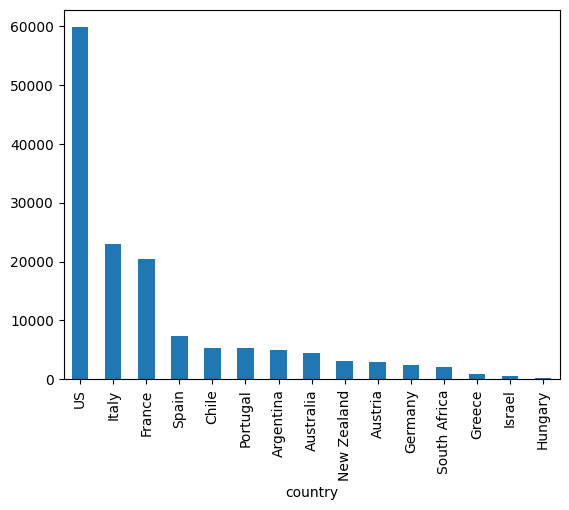

In [21]:
#df2["country"].value_counts().head(15).plot.bar()
df15= df2["country"].value_counts()
df15 = df15.head(15)
df15.plot.bar()

<Axes: xlabel='province'>

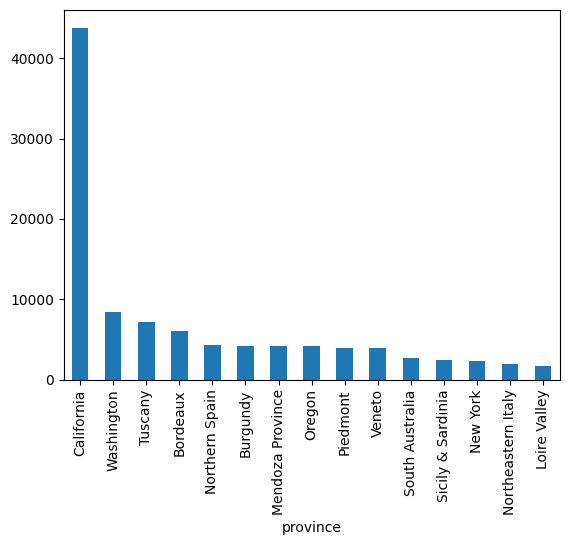

In [18]:
df2["province"].value_counts().head(15).plot.bar()

<Axes: xlabel='points'>

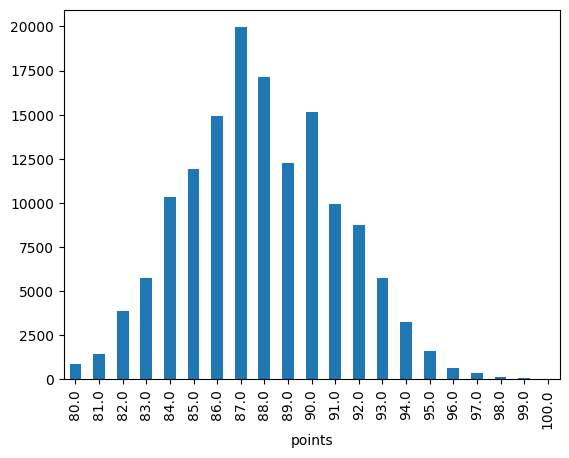

In [22]:
df2["points"].value_counts().sort_index().plot.bar()

<Axes: xlabel='price'>

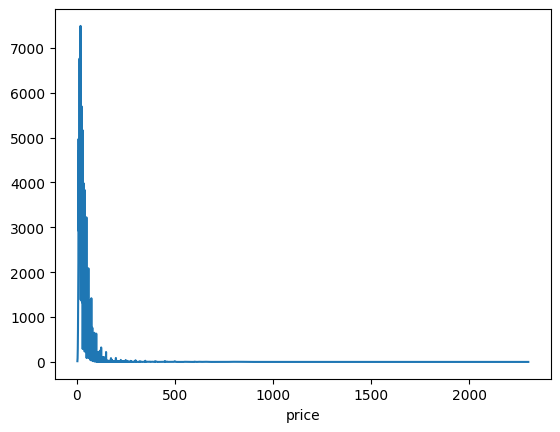

In [24]:
df2["price"].value_counts().sort_index().plot.line()

In [25]:
df2["price"]

0         235.0
1         110.0
2          90.0
3          65.0
4          66.0
          ...  
144032     20.0
144033     27.0
144034     20.0
144035     52.0
144036     15.0
Name: price, Length: 144037, dtype: float64

<Axes: xlabel='price'>

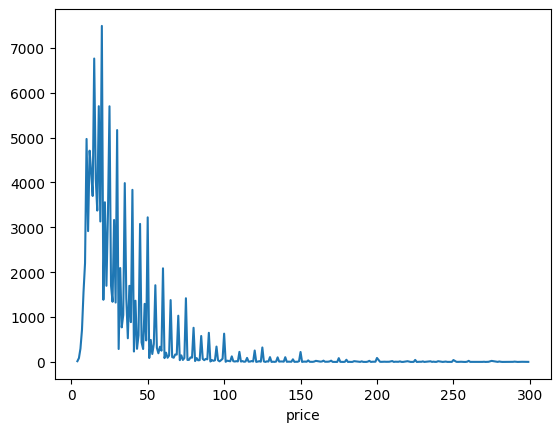

In [26]:
df2.query("price < 300").price.value_counts().sort_index().plot.line()

<Axes: xlabel='price'>

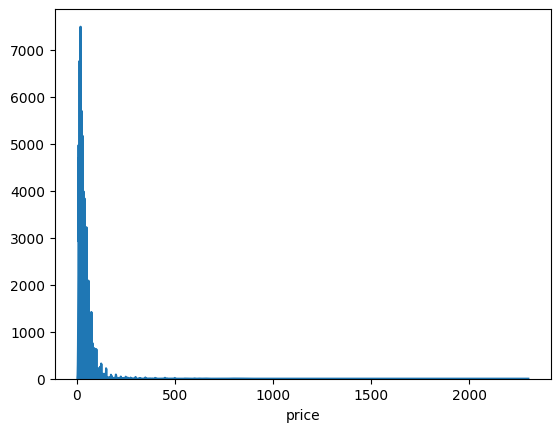

In [27]:
df2["price"].value_counts().sort_index().plot.area()

<Axes: xlabel='last_year_points'>

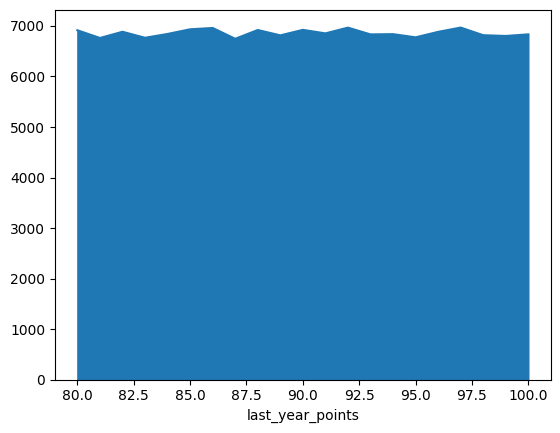

In [35]:
df2["last_year_points"].value_counts().sort_index().plot.area()

<Axes: xlabel='last_year_points', ylabel='price'>

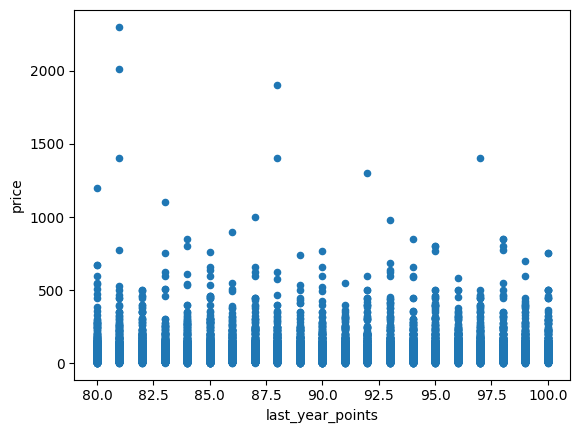

In [37]:
# x= last_year_points y= price
df2.plot.scatter(x = "last_year_points",y="price")

# Cambiar tamaño de la barra y demas configuraciones

<Axes: title={'center': 'Puntos'}, xlabel='points'>

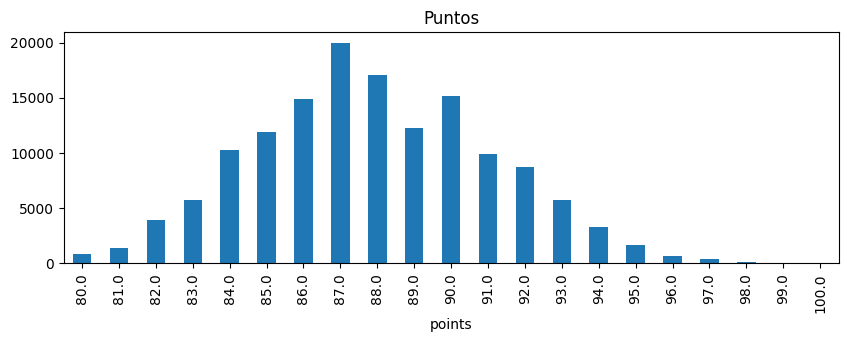

In [41]:
df2["points"].value_counts().sort_index().plot.bar(figsize=(10,3),fontsize=10,title="Puntos")

# Libreria SEABORN - sirve para relaciones y ciencia de datos (mas precisa) 

In [42]:
import seaborn as sns

<Axes: xlabel='count', ylabel='country'>

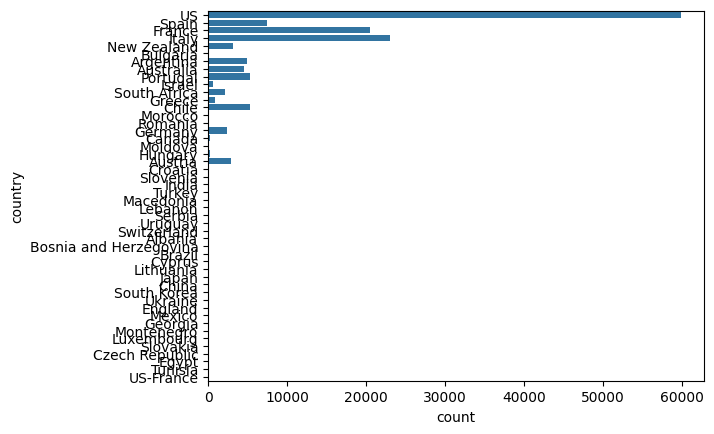

In [55]:
sns.countplot(df2["country"])

# PANDAS: Agrupar y Ordenar - Traer datos poniendo parametros - ejemplo: desde el comiezo hasta los primeros 17 - Traer solo los nombres 

In [64]:
df2.country.value_counts().iloc[:17].index

Index(['US', 'Italy', 'France', 'Spain', 'Chile', 'Portugal', 'Argentina',
       'Australia', 'New Zealand', 'Austria', 'Germany', 'South Africa',
       'Greece', 'Israel', 'Hungary', 'Canada', 'Romania'],
      dtype='object', name='country')

# Primera opcion 

<Axes: xlabel='count', ylabel='country'>

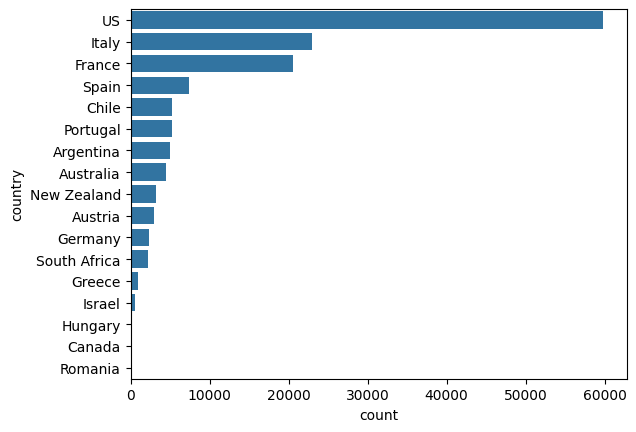

In [65]:
sns.countplot(df2["country"],order=df2.country.value_counts().iloc[:17].index)

# segunda opcion

<Axes: xlabel='count', ylabel='country'>

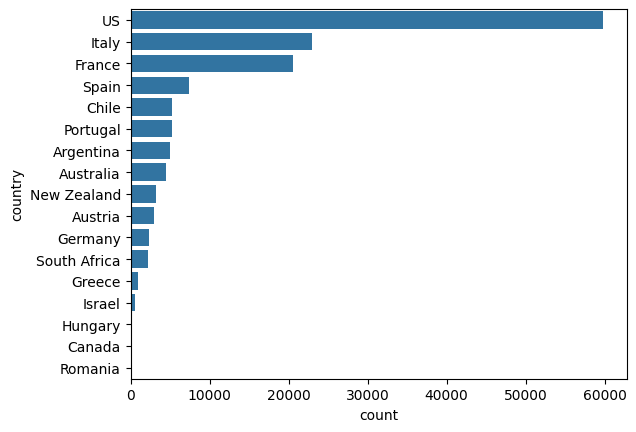

In [70]:
filtro = ['US', 'Italy', 'France', 'Spain', 'Chile', 'Portugal', 'Argentina',
       'Australia', 'New Zealand', 'Austria', 'Germany', 'South Africa',
       'Greece', 'Israel', 'Hungary', 'Canada', 'Romania']
sns.countplot(df2["country"],order=filtro)

# Grafico para medir la densidad (la densida se mide con lineas) - con kdeplot

<Axes: xlabel='price', ylabel='Density'>

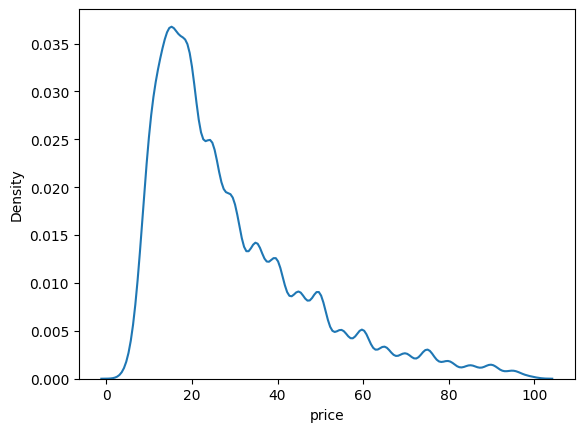

In [71]:
sns.kdeplot(df2.query("price < 100").price)

# Llevar el grafico anterior a una variable - graficar la cantidad, los puntos y la dispersion (50) entre puntos

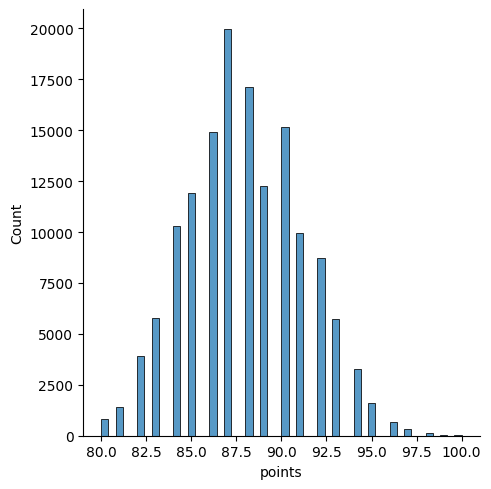

In [73]:
ax = sns.displot(df2["points"],bins=50,kde=False)

# Con dispersion 30

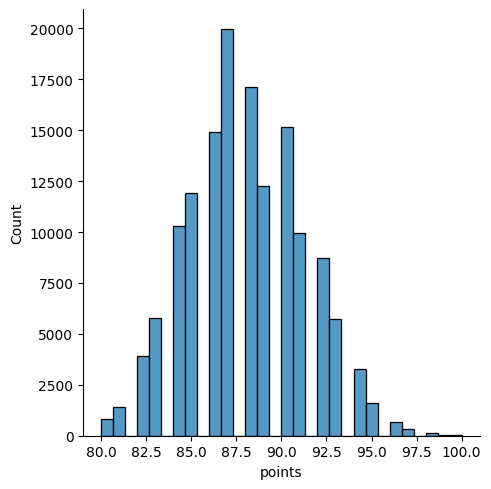

In [74]:
ax = sns.displot(df2["points"],bins=30,kde=False)

# Mostrar superposicion del comportamiento vs la dispersion

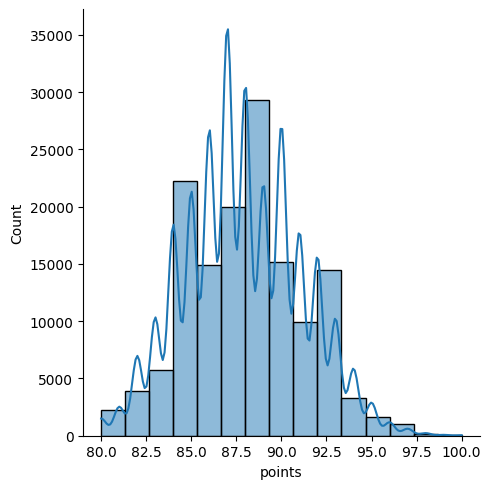

In [75]:
ax = sns.displot(df2["points"],bins=15,kde=True)

# GRAFICOS DE CIENTIFICOS: Graficos de caja negra - 

En el siguiente ejemplo: Le estoy indicando al Dataframe que me filtre por la variedad pero siempre que no este vacia - en variedad estoy indicando traigame los primeros 5 nombres, no los valores. Con ese filtro se asume que estoy pidiendo traer las primeras 5 columnas y me dice de esos datos cuales coinciden y cuales no - VER COLUMBA VARIETY -
# IMPORTANTE Lo primero que se debe hacer es limpiar los datos antes de graficarlos.

In [76]:
df2.variety.value_counts().head(5).index
df2.variety.isin(df2.variety.value_counts().head(5).index)
df2[df2.variety.isin(df2.variety.value_counts().head(5).index)]

,country,designation,points,price,province,region_1,region_2,variety,winery,last_year_points
0,US,Martha's Vineyard,96.0,235.0,California,Napa Valley,Napa,Cabernet Sauvignon,Heitz,94
3,US,Reserve,96.0,65.0,Oregon,Willamette Valley,Willamette Valley,Pinot Noir,Ponzi,94
8,US,Silice,95.0,65.0,Oregon,Chehalem Mountains,Willamette Valley,Pinot Noir,Bergström,83
9,US,Gap's Crown Vineyard,95.0,60.0,California,Sonoma Coast,Sonoma,Pinot Noir,Blue Farm,83
11,US,Estate Vineyard Wadensvil Block,95.0,48.0,Oregon,Ribbon Ridge,Willamette Valley,Pinot Noir,Patricia Green Cellars,88
...,...,...,...,...,...,...,...,...,...,...
144017,France,Les Beaux-Monts,92.0,52.0,Burgundy,Vosne-Romanée,NaN,Pinot Noir,Daniel Rion,98
144018,France,Aux Brulees,90.0,65.0,Burgundy,Vosne-Romanée,NaN,Pinot Noir,Michel Gros,84
144019,France,NaN,89.0,38.0,Burgundy,Chambolle-Musigny,NaN,Pinot Noir,Michel Gros,85
144020,France,Les Chaliots,87.0,37.0,Burgundy,Nuits-St.-Georges,NaN,Pinot Noir,Michel Gros,85


# Despues hago un boxplot con esos datos

<Axes: xlabel='variety', ylabel='points'>

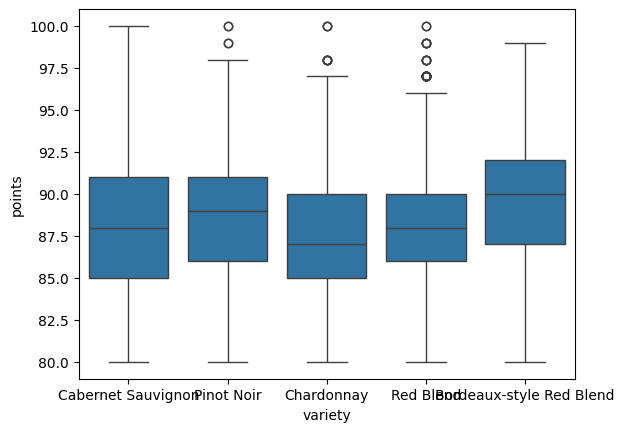

In [77]:
df20= df2[df2.variety.isin(df2.variety.value_counts().head(5).index)]
plt.Figure(figsize=(12,8))
sns.boxplot(x="variety",y="points",data=df20)

# Diferentes Graficos con cada una de las variables

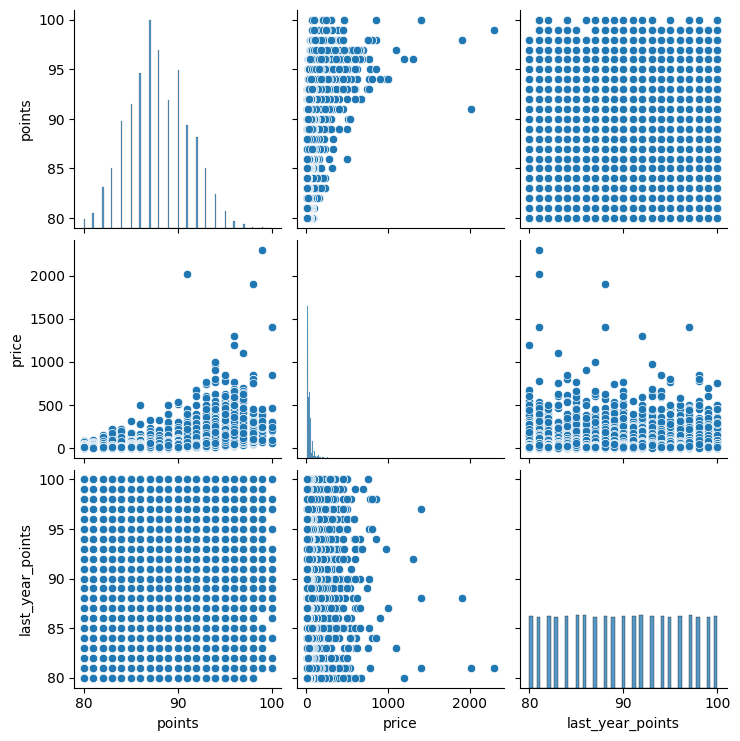

In [78]:
sns.pairplot(df2)

# VISUALIZACION CON DATAFRAME 1

In [79]:
df1.head(13)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


# En este ejercicio se muestra la especie (x), la cantidad (y) por tamaño 

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

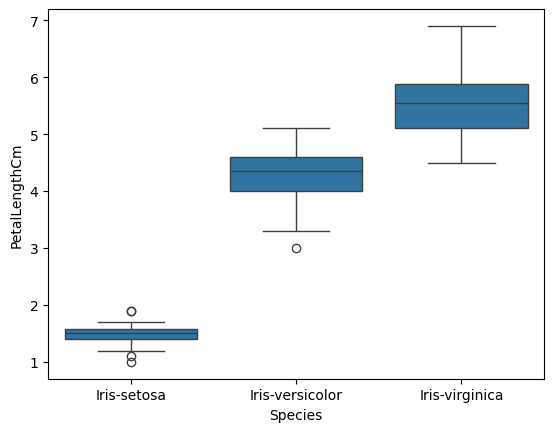

In [80]:
sns.boxplot(x="Species",y="PetalLengthCm",data=df1)

# Graficar y visualizar relaciones entre múltiples variables con PAIRPLOT - Para este ejemplo lo haremos con la variable ESPECIE
axis: orientacion (horizontal o vertical) - size: la cantidad de especies



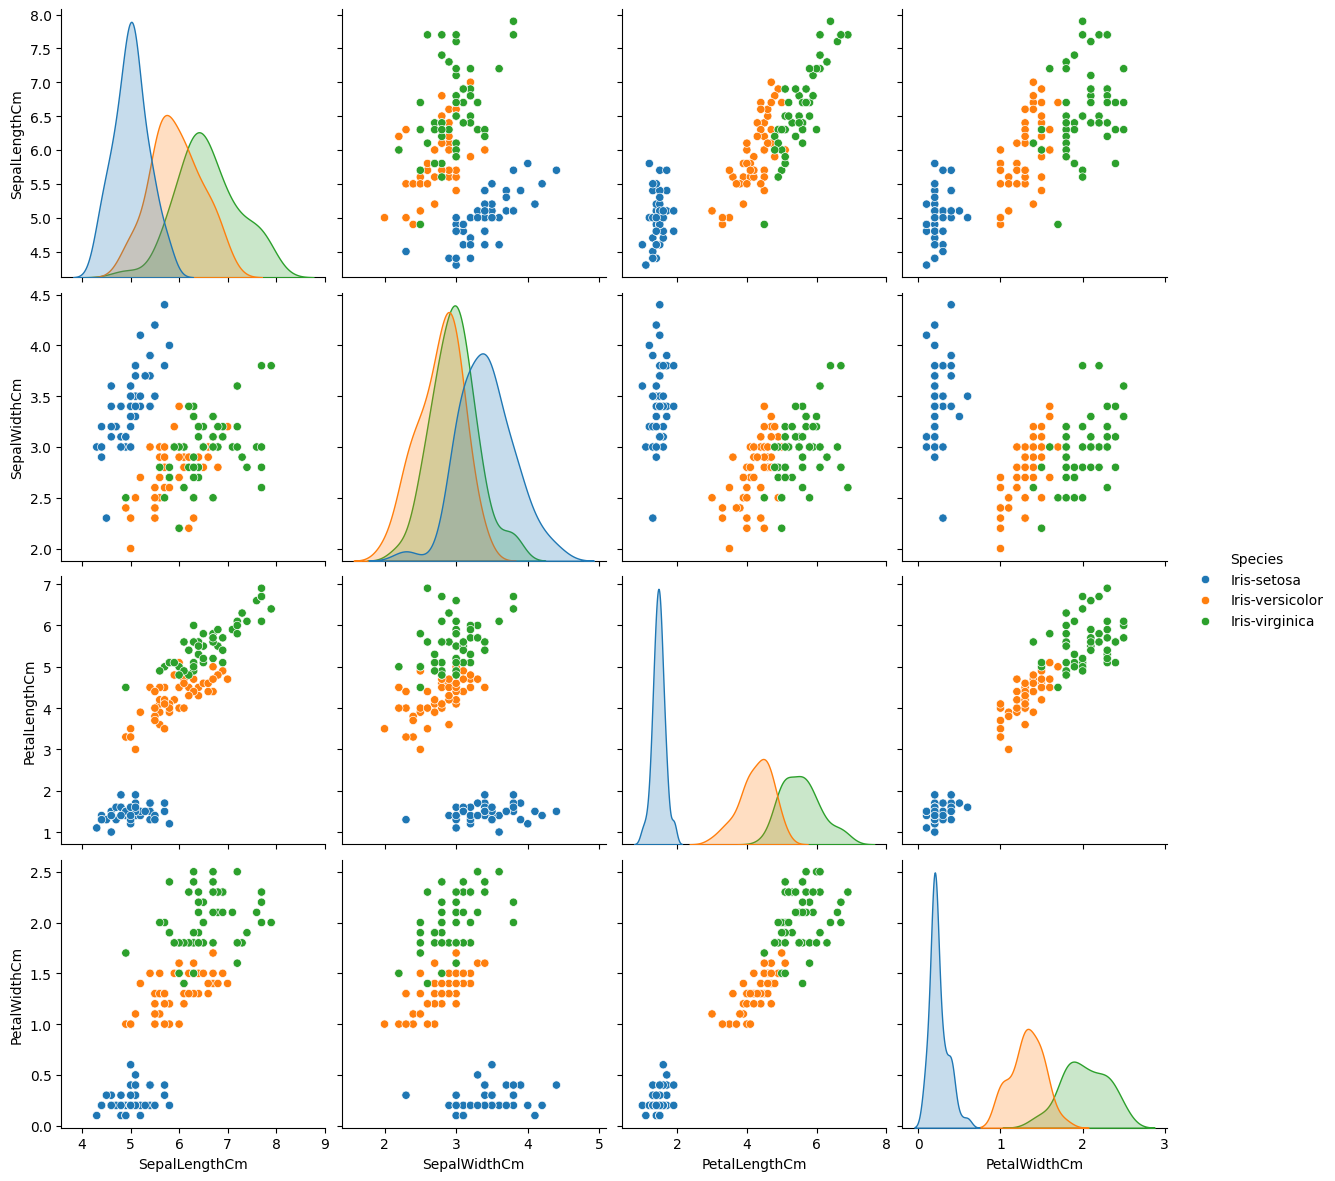

In [81]:
sns.pairplot(df1.drop("Id",axis=1),hue="Species",size=3)

In [1]:
df3 = pd.DataFrame()
dataset = datagen.download_dataset_zip("ardayavuzkeskin/top-ai-tools-popularity-and-valuation") 
csv_dir =datagen.extract_zip_files(dataset)
df3 = datagen.create_csv(csv_dir)

NameError: name 'pd' is not defined